In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# data loading & understanding
df = pd.read_csv("health_data.csv")
df.head()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   70000 non-null  int64  
 1   id           70000 non-null  float64
 2   age          70000 non-null  float64
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  float64
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  float64
 7   ap_lo        70000 non-null  float64
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 7.5 MB


In [4]:
df.describe()

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,34999.500000,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,20207.403759,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17499.750000,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,34999.500000,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,52499.250000,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,69999.000000,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.shape #num of rows & columns

(70000, 14)

In [6]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [7]:
# Missing Values
print(df.isnull().sum())

Unnamed: 0     0
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [8]:
# remove unnecessary columns 
df.drop(columns=['Unnamed: 0'],inplace=True)
df.drop(columns=['id'],inplace=True)
print('shape of the data after dropping unnecessary columns:', df.shape)

shape of the data after dropping unnecessary columns: (70000, 12)


In [9]:
# data cleaning (delete outliers)

print("Data size before cleaning:", df.shape[0])

# Medical logic
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 180)]
df = df[df['ap_hi'] > df['ap_lo']]
# Data Filtering
df = df[(df['height'] > 100) & (df['height'] < 220)]
df = df[(df['weight'] > 30) & (df['weight'] < 200)]

print("Data size after cleaning:", df.shape[0])

Data size before cleaning: 70000
Data size after cleaning: 68613


In [10]:
# convert age in years 
df['age'] = (df['age'] / 365)

print('Minimum age:', df['age'].min(), 'years')
print('Maximum age:', df['age'].max(), 'years')


Minimum age: 29.583561643835615 years
Maximum age: 64.96712328767123 years


In [11]:
# handeling outliers using IQR method
cols_to_cap = ['ap_hi', 'ap_lo', 'height', 'weight']

for col in cols_to_cap:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'{col:12s} → Lower bound: {lower:.1f}  |  Upper bound: {upper:.1f}')

print(f'\nOutliers handled — Data size: {df.shape[0]} rows (no rows removed)')

ap_hi        → Lower bound: 90.0  |  Upper bound: 170.0
ap_lo        → Lower bound: 65.0  |  Upper bound: 105.0
height       → Lower bound: 142.5  |  Upper bound: 186.5
weight       → Lower bound: 39.5  |  Upper bound: 107.5

Outliers handled — Data size: 68613 rows (no rows removed)


In [12]:
# check from Duplicated rows

print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 24


In [13]:
# Remove duplicate rows

before = df.shape[0]  
print('Before removing duplicates:', before, 'rows')
df.drop_duplicates(inplace=True)
after = df.shape[0]  
print('After removing duplicates:', after, 'rows')
print('Removed:', before - after, 'duplicate rows')

Before removing duplicates: 68613 rows
After removing duplicates: 68589 rows
Removed: 24 duplicate rows


In [14]:
# Body mass index مؤشر كتلة الجسم 
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['BMI'] = df['BMI']

print('BMI column added successfully ')

BMI column added successfully 


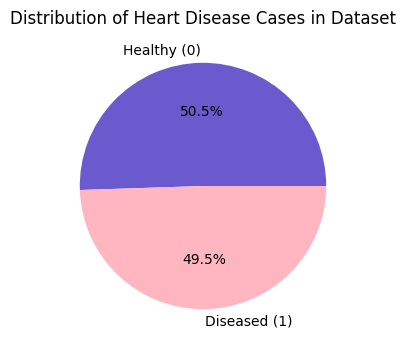

In [15]:
# 4A: Target Distribution (cardio) 
# cardio = 0 → healthy person
# cardio = 1 → person has heart disease

plt.figure(figsize=(5, 4))

df['cardio'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Healthy (0)', 'Diseased (1)'],
    colors=['#6A5ACD', '#FFB6C1']  # soft purple & light pink
)

plt.title('Distribution of Heart Disease Cases in Dataset')
plt.ylabel('')
plt.show()


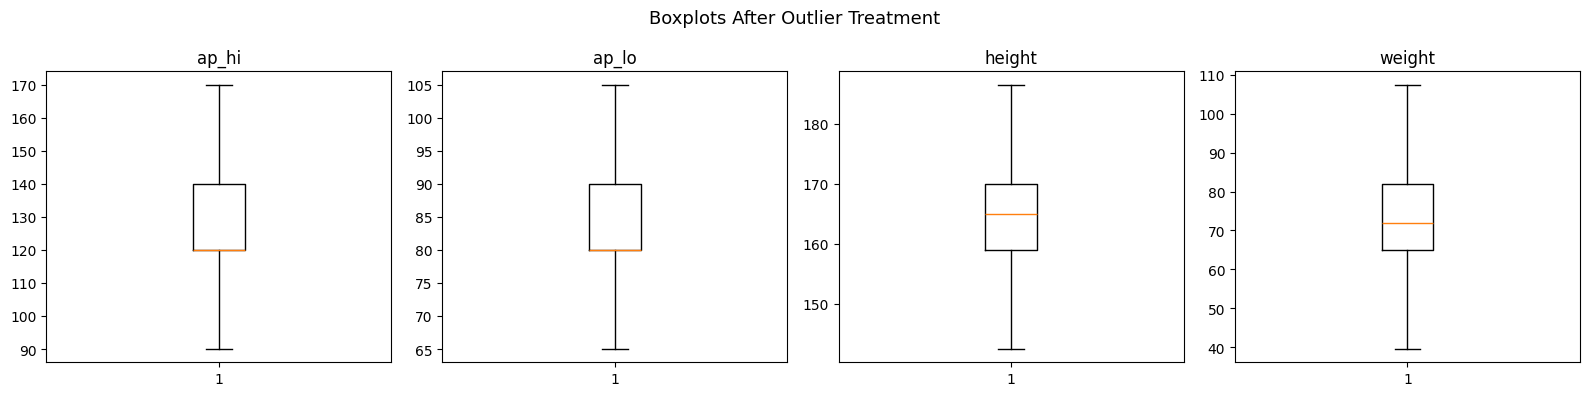

In [16]:

#  verify  outliers have been handled

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Boxplots After Outlier Treatment', fontsize=13)

for ax, col in zip(axes, ['ap_hi', 'ap_lo', 'height', 'weight']):
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()

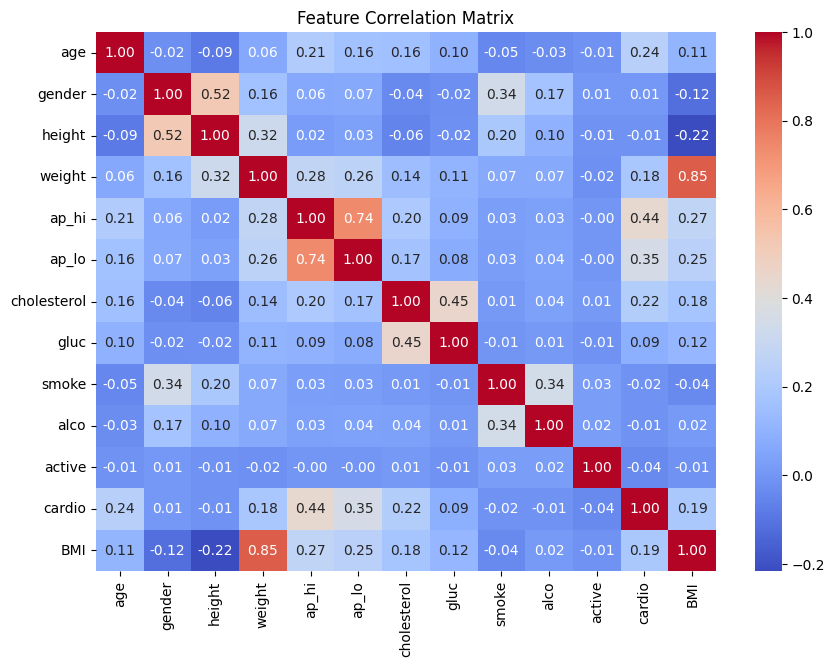

In [17]:
# ── 4C: Correlation Heatmap ───────────────────────────────────
# Correlation shows the relationship between each pair of features
# Close to +1  strong positive correlation
# Close to -1  strong negative correlation
# Close to 0   no clear relationship

plt.figure(figsize=(10, 7))

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Feature Correlation Matrix')
plt.show()

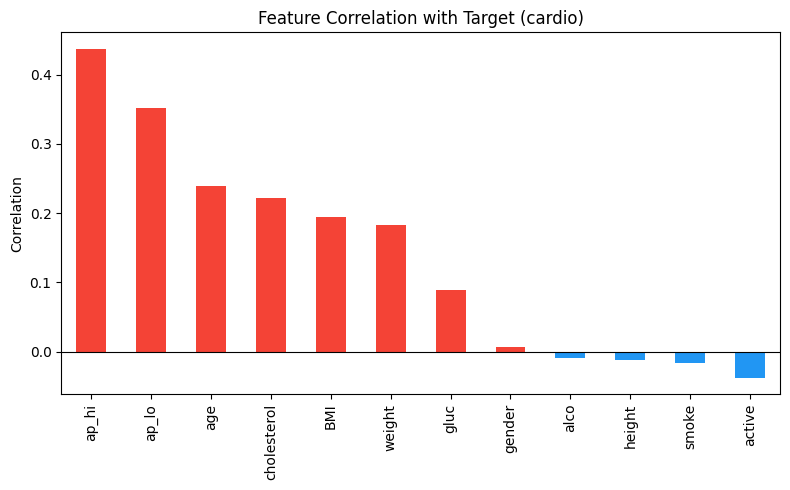


Most Correlated Features with Disease:
ap_hi          0.437548
ap_lo          0.352218
age            0.239369
cholesterol    0.221380
BMI            0.194191
weight         0.183340
gluc           0.089549
gender         0.007108
alco          -0.008679
height        -0.012606
smoke         -0.016319
active        -0.037697
Name: cardio, dtype: float64


In [18]:
# ── 4D: Correlation with Target ───────────────────────────
# analyze which features have the strongest relationship with cardio

corr_with_target = df.corr()['cardio'].drop('cardio').sort_values(ascending=False)

plt.figure(figsize=(8, 5))

corr_with_target.plot(
    kind='bar',
    color=['#F44336' if v > 0 else '#2196F3' for v in corr_with_target]
)

plt.title('Feature Correlation with Target (cardio)')
plt.ylabel('Correlation')
plt.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('\nMost Correlated Features with Disease:')
print(corr_with_target)

In [19]:
# ── 5A: Splitting Features and Target ───────────────────────
# X = input features (what the model learns from)
# y = target variable (what we want to predict)

X = df.drop(columns=['cardio'])   # all columns except cardio
y = df['cardio']                  # only the target column

print('X (Features):', X.shape)
print('y (Target):', y.shape)

print('\nFeature Names:', X.columns.tolist())

X (Features): (68589, 12)
y (Target): (68589,)

Feature Names: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']


In [20]:
from sklearn.model_selection import train_test_split      # تقسيم الداتا
from sklearn.preprocessing import StandardScaler          # تطبيع الأرقام
from sklearn.feature_selection import SelectKBest, f_classif  # Feature Selection
from sklearn.decomposition import PCA                     # Feature Extraction

# النماذج
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# تقييم النماذج
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [21]:
# ── 5B: Splitting Data into Train and Test ────────────────────────
# Train = used to train the model (80% of the data)
# Test  = used to evaluate the model (20% of the data)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # ensures the same split every time we run the code
    stratify=y          # keeps the same class distribution in both train and test sets
)

print('Training Data (Train):', X_train.shape[0], 'rows')
print('Testing Data (Test)  :', X_test.shape[0], 'rows')

Training Data (Train): 54871 rows
Testing Data (Test)  : 13718 rows


In [22]:
#  5C: Feature Scaling 
# StandardScaler normalizes data so all features have the same scale
# This prevents the model from giving higher importance to larger numeric values

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learn scaling from training data only
X_test_scaled  = scaler.transform(X_test)        # apply the same scaling to test data

print('Data scaling completed successfully')

Data scaling completed successfully


In [23]:
#  6A: Feature Selection 
# SelectKBest evaluates which features are most statistically important

selector = SelectKBest(score_func=f_classif, k=7)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
# Learn feature importance from training data and reduce features

X_test_selected = selector.transform(X_test_scaled)
# Apply the same feature selection to test data (no re-learning)

# Create a DataFrame showing feature importance ranking
scores_df = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_,
    'Selected': selector.get_support()
}).sort_values('Score', ascending=False)

print('\nFeature ranking from most important to least important:\n')
print(scores_df.to_string(index=False))


print(f'\nNumber of Features: {X_train_scaled.shape[1]} → {X_train_selected.shape[1]}')


Feature ranking from most important to least important:

    Feature        Score  Selected
      ap_hi 12878.462535      True
      ap_lo  7718.579543      True
        age  3349.707547      True
cholesterol  2773.197227      True
        BMI  2130.382225      True
     weight  1833.265457      True
       gluc   423.282777      True
     active    86.805574     False
      smoke    17.583494     False
     height    16.335763     False
       alco     4.406096     False
     gender     3.769730     False

Number of Features: 12 → 7


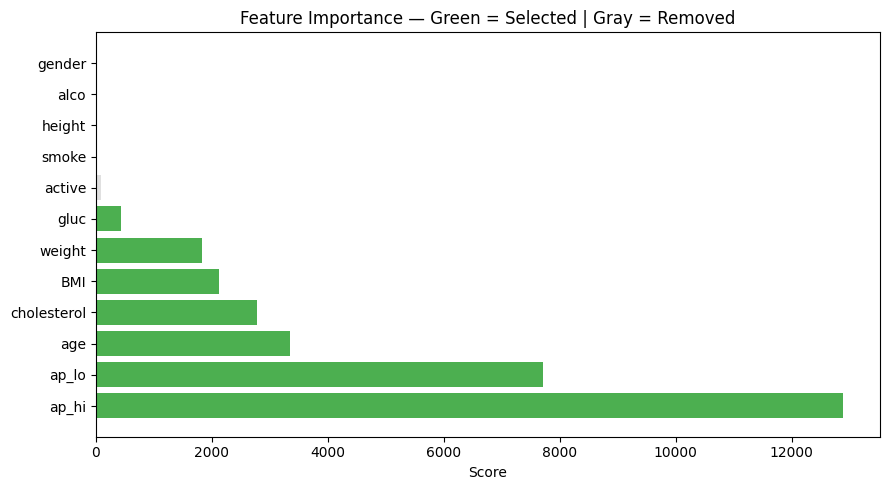

In [24]:
# Feature importance visualization
plt.figure(figsize=(9, 5))

# Green = selected features, Gray = removed features
colors = ['#4CAF50' if s else '#e0e0e0' for s in scores_df['Selected']]

plt.barh(scores_df['Feature'], scores_df['Score'], color=colors)

plt.title('Feature Importance — Green = Selected | Gray = Removed')
plt.xlabel('Score')

plt.tight_layout()
plt.show()


In [25]:

#  PCA
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f'Number of original features        : {X_train_scaled.shape[1]}')
print(f'Number of components after PCA     : {X_train_pca.shape[1]}')
print(f'Explained information retained      : {pca.explained_variance_ratio_.sum()*100:.1f}%')

Number of original features        : 12
Number of components after PCA     : 10
Explained information retained      : 97.8%


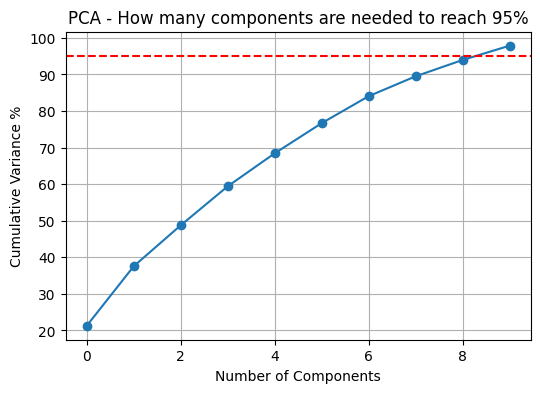

In [26]:
plt.figure(figsize=(6,4))

plt.plot(
    pca.explained_variance_ratio_.cumsum()*100,
    marker='o'
)

plt.axhline(95, color='red', linestyle='--')

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance %')
plt.title('PCA - How many components are needed to reach 95%')

plt.grid()
plt.show()

In [27]:


def train_and_evaluate(model_name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    return acc


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}


#  Original 
print('Original Data')

results_original = {}
for name, model in models.items():
    acc = train_and_evaluate(name, model,
                             X_train_scaled, X_test_scaled,
                             y_train, y_test)
    
    results_original[name] = acc
    print(f"{name}: {acc:.4f}")


#  Feature Selection 

print('After Feature Selection')


results_selected = {}
for name, model in models.items():
    acc = train_and_evaluate(name, model,
                             X_train_selected, X_test_selected,
                             y_train, y_test)
    
    results_selected[name] = acc
    print(f"{name}: {acc:.4f}")


# PCA

print('After PCA')


results_pca = {}
for name, model in models.items():
    acc = train_and_evaluate(name, model,
                             X_train_pca, X_test_pca,
                             y_train, y_test)
    
    results_pca[name] = acc
    print(f"{name}: {acc:.4f}")

Original Data
Decision Tree: 0.6370
Random Forest: 0.7110
KNN: 0.6959
After Feature Selection
Decision Tree: 0.6369
Random Forest: 0.7077
KNN: 0.6979
After PCA
Decision Tree: 0.6277
Random Forest: 0.7078
KNN: 0.6910


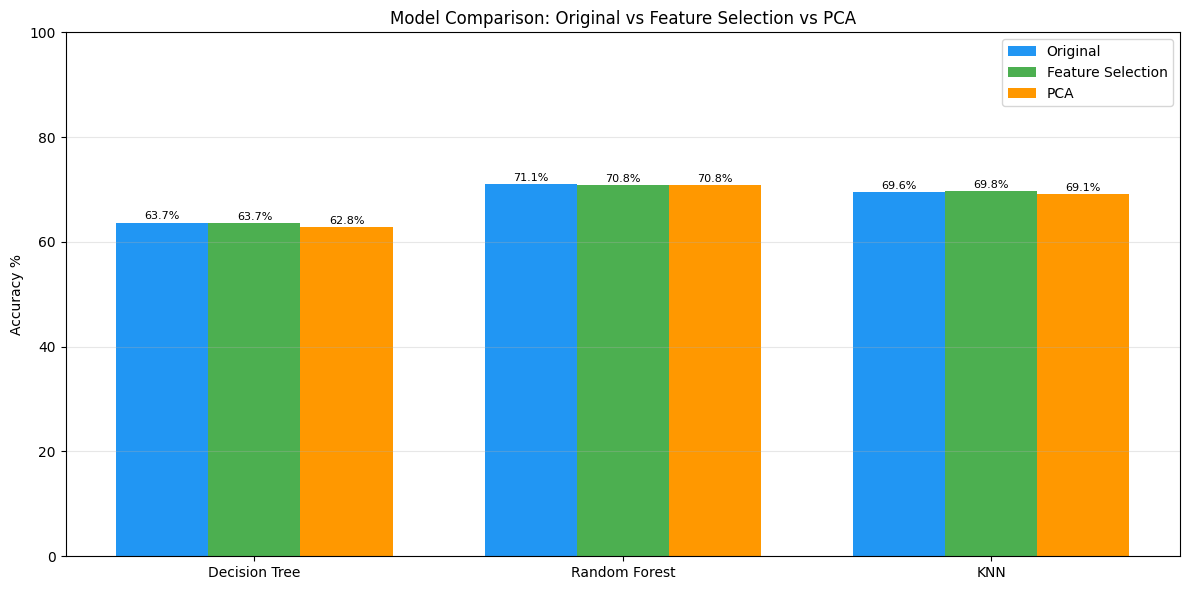

In [28]:
# Bar Chart Comparison 

model_names = list(models.keys())
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width,
               [results_original[n] * 100 for n in model_names],
               width, label='Original', color='#2196F3')

bars2 = ax.bar(x,
               [results_selected[n] * 100 for n in model_names],
               width, label='Feature Selection', color='#4CAF50')

bars3 = ax.bar(x + width,
               [results_pca[n] * 100 for n in model_names],
               width, label='PCA', color='#FF9800')

# values on top of bars 
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%',
                ha='center', va='bottom', fontsize=8)

# styling 
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Accuracy %')
ax.set_title('Model Comparison: Original vs Feature Selection vs PCA')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()